# 第一部分: 校准分析

  [图] 14c_hl_test.png → Hosmer-Lemeshow 检验已保存


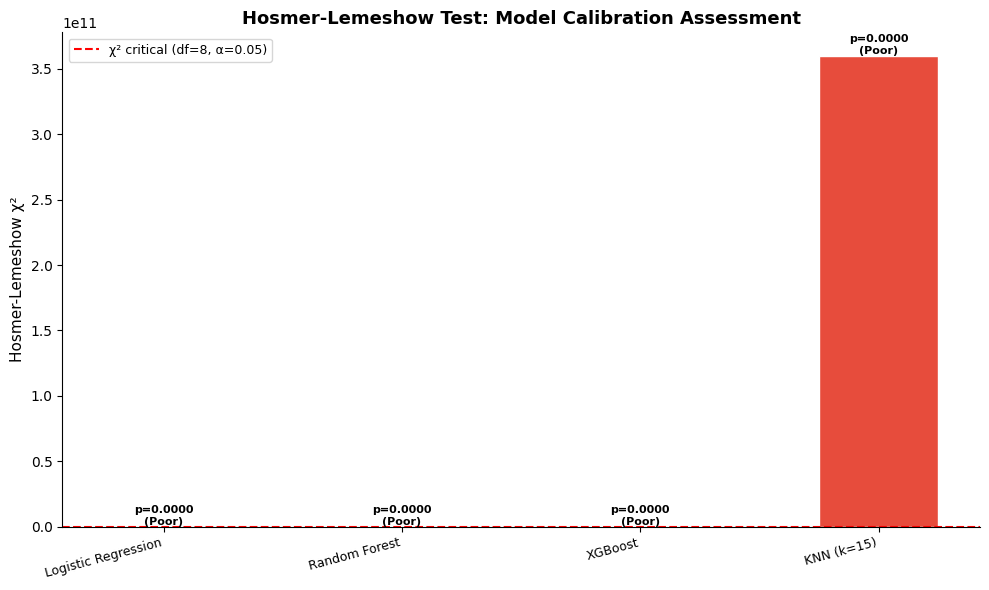

In [13]:
# --- 图 3: 校准度直方图 ---
fig, ax = plt.subplots(figsize=(10, 6))
names_hl = list(hl_results.keys())
chi2s = [hl_results[n]['chi2'] for n in names_hl]
ps = [hl_results[n]['p'] for n in names_hl]

colors_hl = ['#2ecc71' if p > 0.05 else '#e74c3c' for p in ps]
bars = ax.bar(range(len(names_hl)), chi2s, color=colors_hl, edgecolor='white', width=0.5)
ax.axhline(y=15.507, color='red', linestyle='--', linewidth=1.5,
           label='χ² critical (df=8, α=0.05)')
ax.set_xticks(range(len(names_hl)))
ax.set_xticklabels(names_hl, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Hosmer-Lemeshow χ²', fontsize=11)
ax.set_title('Hosmer-Lemeshow Test: Model Calibration Assessment',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, p in zip(bars, ps):
    status = 'Good' if p > 0.05 else 'Poor'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'p={p:.4f}\n({status})', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14c_hl_test.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 14c_hl_test.png → Hosmer-Lemeshow 检验已保存")

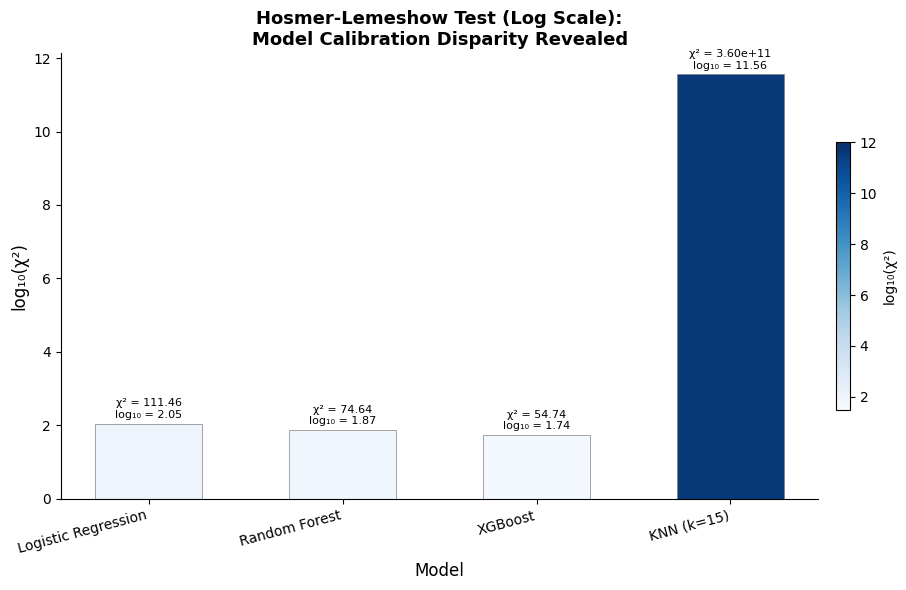

In [24]:
# --- 图 14c 优化版: 对数坐标 Hosmer-Lemeshow ---
fig, ax = plt.subplots(figsize=(10, 6))
names_hl = list(hl_results.keys())

# 对数变换: log10(χ²)
chi2s_raw = np.array([hl_results[n]['chi2'] for n in names_hl])
chi2s_log = np.log10(np.maximum(chi2s_raw, 1))  # 防止 log(0)
ps = [hl_results[n]['p'] for n in names_hl]

# 着色方案: 用颜色深浅表示 χ² 大小，不再只用红/绿二值
# 色阶映射: log10(χ²) 范围 [1.7, 11.6]，映射到蓝色色阶
norm = plt.Normalize(vmin=1.5, vmax=12)
cmap = plt.cm.Blues
colors_log = cmap(norm(chi2s_log))

bars = ax.bar(range(len(names_hl)), chi2s_log, color=colors_log,
              edgecolor='gray', linewidth=0.5, width=0.55)

# 标注原始 χ² 值（用科学计数法显示）
for i, (bar, raw, logv) in enumerate(zip(bars, chi2s_raw, chi2s_log)):
    if raw > 1e6:
        label = f'χ² = {raw:.2e}\nlog₁₀ = {logv:.2f}'
    else:
        label = f'χ² = {raw:.2f}\nlog₁₀ = {logv:.2f}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            label, ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(len(names_hl)))
ax.set_xticklabels(names_hl, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('log₁₀(χ²)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Hosmer-Lemeshow Test (Log Scale):\nModel Calibration Disparity Revealed',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加色阶 colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.6)
cbar.set_label('log₁₀(χ²)', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14c_hl_test_logscale.png"),
            dpi=150, bbox_inches='tight')

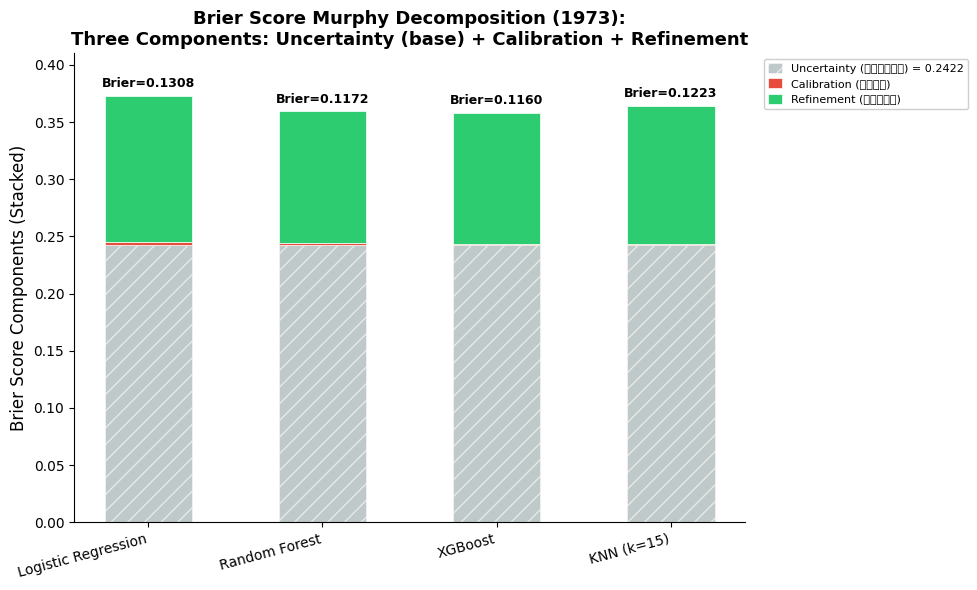

In [25]:
# --- 图 14c 替代方案: Brier Murphy 三成分完整堆叠图 ---
# 堆叠顺序: 底部 = Uncertainty (固定基线) → 中部 = Calibration → 顶部 = Refinement

fig, ax = plt.subplots(figsize=(10, 6))

models_list = list(calibration_data.keys())
n_models = len(models_list)

# 从 brier_decomposition() 获取三成分
refinement = []
calibration = []
uncertainty_arr = []

for name in models_list:
    ref, cal, unc = brier_decomposition(y_te, calibration_data[name]['y_prob'])
    refinement.append(ref)
    calibration.append(cal)
    uncertainty_arr.append(unc)  # 通常 = ȳ(1-ȳ) ≈ 0.2422，所有模型相同

x = np.arange(n_models)
width = 0.5

# ① 底层: Uncertainty（灰斜线）—— 固有不确定性，作为"基线"显示在最下方
uncertainty_display = uncertainty_arr[0]  # 用第一个模型的值（理论上都相同）
bars_unc = ax.bar(x, uncertainty_arr, width,
                  label=f'Uncertainty (固有不确定性) = {uncertainty_display:.4f}',
                  color='#95a5a6', edgecolor='white', linewidth=0.5,
                  alpha=0.6, hatch='//')

# ② 中层: Calibration（红）—— 校准误差，在 Uncertainty 之上
bars_cal = ax.bar(x, calibration, width,
                  bottom=uncertainty_arr,
                  label='Calibration (校准误差)',
                  color='#e74c3c', edgecolor='white', linewidth=0.5)

# ③ 顶层: Refinement（绿）—— 鉴别力贡献，在最上方
bars_ref = ax.bar(x, refinement, width,
                  bottom=[u + c for u, c in zip(uncertainty_arr, calibration)],
                  label='Refinement (鉴别力贡献)',
                  color='#2ecc71', edgecolor='white', linewidth=0.5)

# 柱顶标注 Brier Score（= Ref + Cal，不含 Uncertainty）
for i in range(n_models):
    brier_total = refinement[i] + calibration[i]
    ax.text(x[i], brier_total + uncertainty_display + 0.005,
            f'Brier={brier_total:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Brier Score Components (Stacked)', fontsize=12)
ax.set_title('Brier Score Murphy Decomposition (1973):\n'
             'Three Components: Uncertainty (base) + Calibration + Refinement',
             fontsize=13, fontweight='bold')

# 图例缩小: 小字号 + 小标记 + 紧内边距, 移到右侧空白区
legend = ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1), framealpha=0.95,
                   handlelength=1.2, handleheight=1.0,
                   borderpad=0.4, labelspacing=0.4,
                   markerscale=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 显式设置 Y 轴上限
ax.set_ylim(0, max(u + r + c for u, r, c in zip(uncertainty_arr, refinement, calibration)) * 1.10)

plt.tight_layout()
fig.subplots_adjust(right=0.75)
plt.savefig(os.path.join(IMG_DIR, "14c_brier_decomposition_three.png"),
            dpi=150, bbox_inches='tight')

# 第二部分: 决策曲线分析 (DCA)

  [图] 14d_dca_curves.png → DCA 曲线已保存


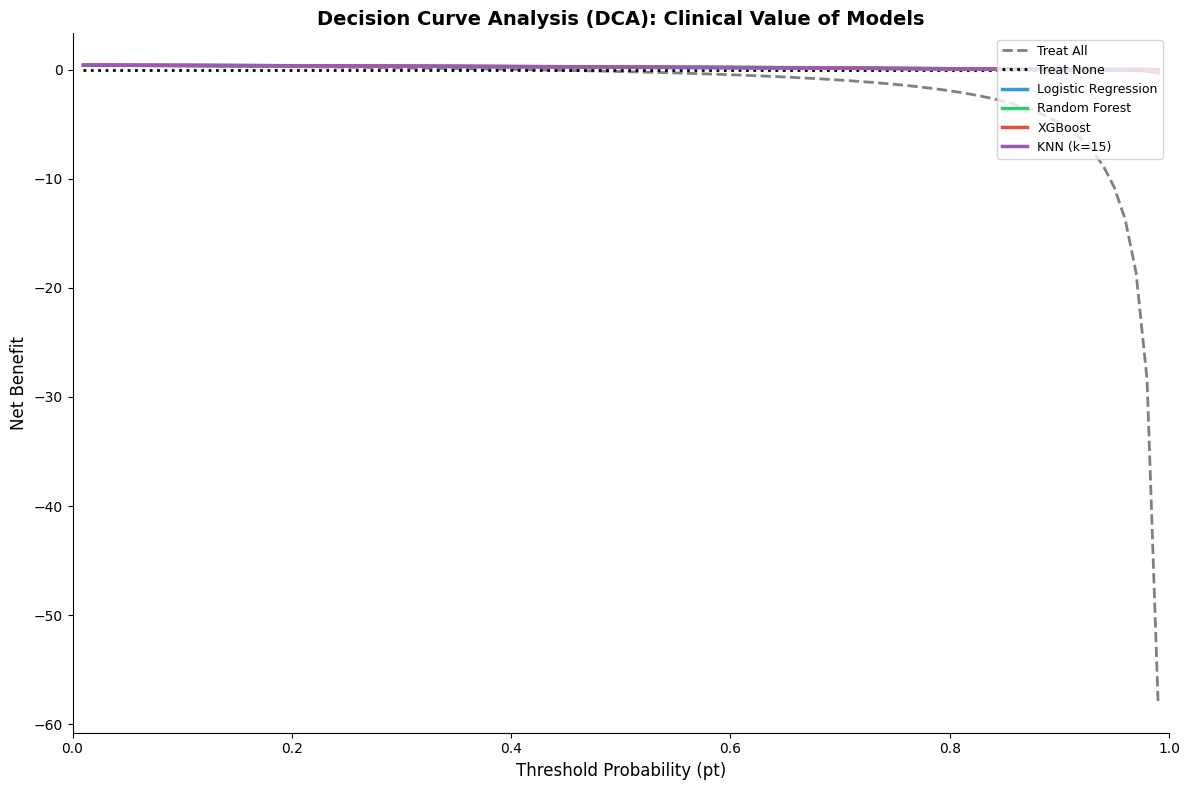

In [16]:
# --- 图 4: DCA 曲线 ---
fig, ax = plt.subplots(figsize=(12, 8))

# Treat All
ax.plot(thresholds, nb_treat_all, '--', color='gray', linewidth=2,
        label='Treat All')
# Treat None
ax.plot(thresholds, nb_treat_none, ':', color='black', linewidth=2,
        label='Treat None')

# 模型
for idx, (name, nb) in enumerate(dca_results.items()):
    ax.plot(thresholds, nb, '-', color=colors_cc[idx % len(colors_cc)],
            linewidth=2.5, label=f'{name}')

ax.set_xlabel('Threshold Probability (pt)', fontsize=12)
ax.set_ylabel('Net Benefit', fontsize=12)
ax.set_title('Decision Curve Analysis (DCA): Clinical Value of Models',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14d_dca_curves.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 14d_dca_curves.png → DCA 曲线已保存")

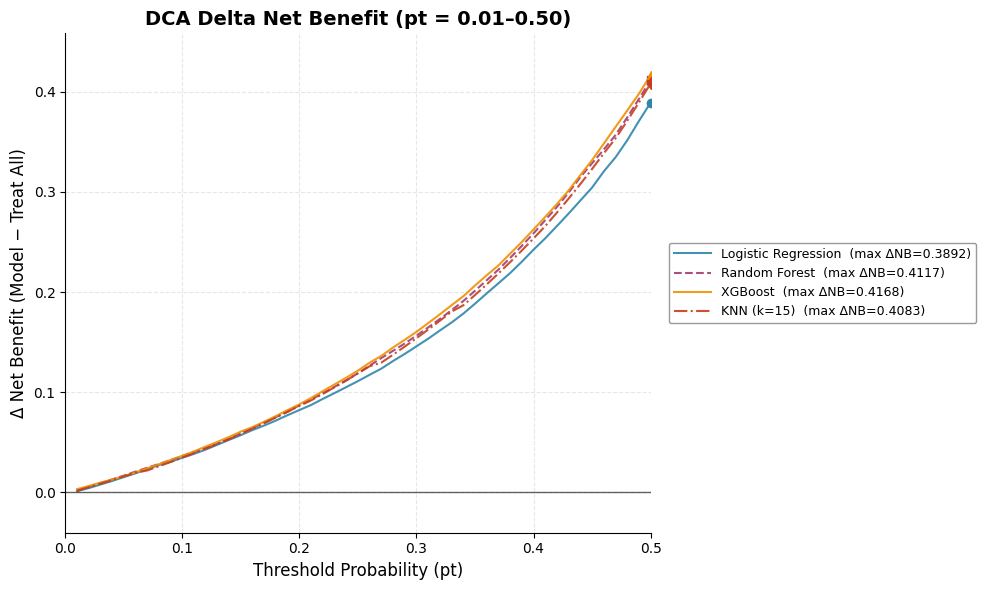

In [26]:
import numpy as np
import matplotlib.pyplot as plt

model_styles = {
    'Logistic Regression': {'color': '#2E86AB', 'linestyle': '-',  'marker': 'o'},
    'Random Forest':     {'color': '#A23B72', 'linestyle': '--', 'marker': 's'},
    'XGBoost':           {'color': '#F18F01', 'linestyle': '-',  'marker': '^'},
    'KNN (k=15)':        {'color': '#C73E1D', 'linestyle': '-.', 'marker': 'd'}
}

fig, ax = plt.subplots(figsize=(10, 6))

mask = (thresholds >= 0.01) & (thresholds <= 0.5)
plot_pt = thresholds[mask]
plot_treat = nb_treat_all[mask]

all_delta = []
for name, nb in dca_results.items():
    delta = nb[mask] - plot_treat
    all_delta.append(delta)
    style = model_styles.get(name, {})
    
    max_idx = np.argmax(delta)
    max_delta = delta[max_idx]
    
    # 关键：图例只显示 max ΔNB，不再显示 @ pt=0.50
    label = f'{name}  (max ΔNB={max_delta:.4f})'
    
    ax.plot(plot_pt, delta, color=style['color'], linewidth=1.5,
            linestyle=style['linestyle'], label=label, alpha=0.9)
    
    # 最大值点标记仍然保留（都在 pt=0.5 处）
    ax.plot(plot_pt[max_idx], max_delta, marker=style['marker'],
            color=style['color'], markersize=6, zorder=5)

all_delta_arr = np.concatenate(all_delta)
y_min, y_max = all_delta_arr.min(), all_delta_arr.max()
margin = 0.1 * (y_max - y_min)

ax.axhline(y=0, color='black', linewidth=1.0, linestyle='-', alpha=0.6)

ax.set_xlim(0, 0.5)
ax.set_ylim(y_min - margin, y_max + margin)

ax.set_xlabel('Threshold Probability (pt)', fontsize=12)
ax.set_ylabel('Δ Net Benefit (Model − Treat All)', fontsize=12)
ax.set_title('DCA Delta Net Benefit (pt = 0.01–0.50)', fontsize=14, fontweight='bold')

ax.legend(fontsize=9, loc='center left', frameon=True,
          bbox_to_anchor=(1.02, 0.5), edgecolor='gray',
          handlelength=3, numpoints=1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14d_dca_delta_nb_v5.png"),
            dpi=150, bbox_inches='tight')